**Mubaraq Odumeso**|
A20614610 |
CS584 |
Spring 2026

# Assignment 3

## Sample code

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
# Example: load digits dataset (image data)
from sklearn.datasets import load_digits
from sklearn.datasets import load_iris

digits = load_digits()
iris = load_iris()
# X, y = digits.data, digits.target
X, y = iris.data, iris.target
# Example: reduce to 2 classes for binary logistic regression
mask = (y == 0) | (y == 1)
X, y = X[mask], y[mask]
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)


# Evaluation helper
def evaluate(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    return cm, prec, rec, f1, acc
# Logistic Regression placeholder
def logistic_train(X, y, lr=0.01, epochs=1000):
    # TODO: implement training
    pass
    # return batch_gradient_ascent(X, y, lr, epochs)
    

def logistic_predict(X, theta):
    # TODO: implement prediction
    pass
    # return predict(X, theta=theta)


In [2]:

## 10 Fold CV  
SEED = 42
def split_for_kcv(X, y, seed = SEED):
    """returns: X_split and y_split"""
    rng = np.random.default_rng(seed = seed)
   
    indices = rng.permutation(len(X))

    X_shuffled = X[indices]
    y_shuffled = y[indices]
    k =10
    X_split = np.array_split(X_shuffled, k)
    y_split = np.array_split(y_shuffled, k)

    return X_split, y_split
    
def print_10_cv(mean_std):
    print("Evaluation (10-fold CV)\n" + "-"*28)
    print(f"Accuracy : {mean_std['acc']}")
    print(f"Precision: {mean_std['prec']}")
    print(f"Recall   : {mean_std['rec']}")
    print(f"F1-score : {mean_std['f1']}")
    print(f"ConfMat  :\n {mean_std['cm']}\n")
def get_classes(y, count: bool = True):
    """returns number of classes"""

    classes = np.unique(y)
    if not count:
        return classes
    n_classes = len(classes)
  
    return n_classes
def get_polynomial(X, degree):
    
    X_poly = np.hstack([X ** (d) for d in range(1, degree + 1)])
   
    return X_poly

def build_poly_and_standardize(degree, X_train, X_test=None):
    """Build polynomial features (x, x^2, ..., x^d) on train; fit mean/std on train; standardize train and optionally test."""
    X_tr_poly = np.hstack([X_train ** (d) for d in range(1, degree + 1)])
    mean_tr = np.mean(X_tr_poly, axis=0)
    std_tr = np.std(X_tr_poly, axis=0)
    std_tr_safe = np.where(std_tr == 0, 1.0, std_tr)
    X_tr_std = (X_tr_poly - mean_tr) / std_tr_safe
    if X_test is None:
        return X_tr_std, mean_tr, std_tr_safe
    X_te_poly = np.hstack([X_test ** (d) for d in range(1, degree + 1)])
    X_te_std = (X_te_poly - mean_tr) / std_tr_safe  # fix 2: same mean/std as train, no recomputation on test
    return X_tr_std, X_te_std, mean_tr, std_tr_safe


get_classes(y)
def ten_cross_validation(X, y,predict: object,family: object ,seed: int = SEED, degree: int = None, lamda = None):
    """params: 
        X: X_train
        y: y_train
        family: prediction_method
        seed: Optional default SEED
        predict: object 
        degree: int = 10
        """
        

    cm_lst, prec_lst, rec_lst, f1_lst, acc_lst = [], [], [], [], []
    all_true_y = []
    n_classes = get_classes(y)
    conf_matrix =  np.zeros((n_classes, n_classes), dtype=int)
    all_pred = []
    X_split, y_split = split_for_kcv(X, y, seed = SEED)
    for i in range(len(X_split)):
        X_sub = X_split.copy()
        y_sub = y_split.copy()
        
        X_val = X_sub.pop(i)
        y_val = y_sub.pop(i)
        
        X_tr = np.vstack(X_sub)
        y_tr = np.hstack(y_sub)
        
        if degree:

            X_tr_std, X_val_std, _fold_means, _fold_stds = build_poly_and_standardize(
                degree, X_tr, X_val
            )
            X_tr = X_tr_std
            X_val = X_val_std
        ##model train      
        thetas = family(X_tr,y_tr, lamda=lamda)
        ## model predict
        y_pred = predict(X_val, theta=thetas)
        
        
        if type(y_pred) == tuple and len(y_pred) >0:            
            y_pred = y_pred[0]
        all_true_y.extend(y_val)
        all_pred.extend(y_pred)
        
        cm, prec, rec, f1, acc = evaluate(y_val, y_pred)
          
        
        for i, c in enumerate(cm):
            for cc in range(len(c)): 
                conf_matrix[i, cc] += cm[i , cc]
        prec_lst.append(prec)
        rec_lst.append(rec)
        f1_lst.append(f1)
        acc_lst.append(acc)
    df = pd.DataFrame(
        conf_matrix, 
        index=[f"Actual {name}" for name in range(n_classes)],
        columns=[f"Pred {name}" for name in range(n_classes)]
    )
    
    acc_mean = [np.mean(acc_lst), np.std(acc_lst)]
    prec_mean = [np.mean(prec_lst), np.std(prec_lst)]
    rec_mean  = [np.mean(rec_lst),  np.std(rec_lst)]
    f1_mean   = [np.mean(f1_lst),   np.std(f1_lst)]

    
    mean_std = {
    "acc": f"{acc_mean[0]:.4f}±{acc_mean[1]:.4f}",
    "prec": f"{prec_mean[0]:.4f}±{prec_mean[1]:.4f}",
    "rec": f"{rec_mean[0]:.4f}±{rec_mean[1]:.4f}",
    "f1": f"{f1_mean[0]:.4f}±{f1_mean[1]:.4f}",
    "cm": df,
    "all_pred" : all_pred,
    "all_true_y" :  all_true_y
    }

    print_10_cv(mean_std)
    return mean_std
        

In [3]:


import pandas as pd
import numpy as np

def display_confusion_matrix(y_true, y_pred, class_names=None):

    classes = np.unique(np.concatenate([y_true, y_pred]))
    n_classes = len(classes)
    

    matrix = np.zeros((n_classes, n_classes), dtype=int)
    
    for i, actual in enumerate(classes):
        for j, predicted in enumerate(classes):
            matrix[i, j] = np.sum((y_true == actual) & (y_pred == predicted))
    

    if class_names is None:
        class_names = [f"Class {c}" for c in classes]
        
    df = pd.DataFrame(
        matrix, 
        index=[f"Actual {name}" for name in class_names],
        columns=[f"Pred {name}" for name in class_names]
    )
 
    return df

In [4]:
def print_evaluation(y_true, y_pred, sanity_ev:bool = False, model_name: str = None, data_type: str = 'Test'):
    """
    params: 
        sanity_ev: bool (This is for sanity comparisons)
        y_pred: if sanity_ev (y_scikit, y_manual)
    returns: cm, prec, rec, f1, acc"""
    if sanity_ev:
        y_manual = y_pred[1]
        y_scikit = y_pred[0]
        # for y_pre in y_pred:
        cm, prec, rec, f1, acc = evaluate(y_true, y_scikit) 
        sk_evaluations =[acc, prec, rec, f1]#scikit evaluations
        cm, prec, rec, f1, acc = evaluate(y_true, y_manual) #manual evaluations
        manual_evaluations =[acc, prec, rec, f1]#scikit evaluations
        
        df = pd.DataFrame({
            "Metric": ["Accuracy", "Precision", "Recall", "F1"],
            "Ours": manual_evaluations,
            f"sklearn ({model_name})": sk_evaluations,
        })
        # 
        print(df)
        
        return  
    
    cm, prec, rec, f1, acc = evaluate(y_true, y_pred)
    print("="*30)
    print(f"   MODEL EVALUATION REPORT ({data_type})")
    print("="*30)
    print(f"Confusion Matrix:")
    print(display_confusion_matrix(y_true, y_pred))
    print("-"*30)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("="*30)
    
    
    
    

## Problem 1.1
Logistic regression for two-class discrimiantion

**sigmoid hypothesis**
$$h_\theta{(x)} = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}​$$
**Stable sigmoid**
$$h_\theta{(x)} = g(\theta^T x) = \frac{e^{\theta^T x}}{1 + e^{\theta^T x}}​$$


**Log likelihood**
$$= \sum_{i=1}^m y^{(i)} \log{h_\theta{(x^{(i)})}} + (1 - y^{(i)}) \log{(1 - h_\theta{(x^{(i)})})}$$

**batch gradient ascent**
- gradient: $$∇_θ​ℓ(θ)=X^T(y−h_θ​(X))$$
- update rule $$θ:=θ+α⋅∇θ_​ℓ(θ)$$ $$\theta_j := \theta_j + \alpha \sum_{i=1}^m (y^{(i)} - h_\theta{(x^{(i)})}) x_j^{(i)}$$

### Newton's Method
$$H=−X^TRX$$
$$R_{ii}​=h_θ​(x^{(i)})⋅(1−h_θ​(x^{(i)}))$$

In [5]:

def stable_sigmoid(X, theta):
    Z = np.dot(X, theta)
    Z = np.clip(Z, -700, 700)   # so exp(±Z) never overflows
    return 1 / (1 + np.exp(-Z))

def newton_method(X_tr ,y_tr, epoch=1000, lamda= 1e-5):
    theta = np.zeros(X_tr.shape[1]) # assume theta (size =  feature )
   
    
    for _ in range(epoch):
        h_theta = stable_sigmoid(X_tr, theta)## sigmoid predictor
        
        
        error = y_tr - h_theta
        
     
        gradient = X_tr.T@ error
        
        R_ii = h_theta * (1- h_theta)

        H = X_tr.T @ (R_ii[:, None] * X_tr)
              
        reg_term = lamda * np.eye(H.shape[0])
        delta = np.linalg.solve(H - reg_term, gradient) # update function
        theta = theta - delta
        
        
        ## stop criteria
        if np.linalg.norm(gradient) < 1e-6: 

            break
     
    return theta

In [6]:

def predict(X, theta) -> list:
    """return: classes"""
    y_pred = stable_sigmoid(X, theta)
    classes = (y_pred >= 0.5).astype(int)
    return classes

In [7]:


def batch_gradient_ascent(X_tr ,y_tr, lr=0.001, epoch=1000, lamda = 0.1):
    
    theta = np.zeros(X_tr.shape[1]) # assume theta (size =  feature )
    
    for _ in range(epoch):
       
        h_theta =stable_sigmoid(X_tr, theta) ## sigmoid predictor
        
        
        error = y_tr - h_theta
       
        gradient = X_tr.T@ error 
        
        reg_theta = np.copy(theta)
        reg_theta[0] = 0
        
        gradient -= lamda * reg_theta
        

        theta += lr * gradient # update function
        ## stop criteria
        if np.linalg.norm(gradient) < 1e-4: 
            print("Escape via norm(gradient criteria)")
            break
     
    return theta



print(X_train.shape)
ten_cross_validation(X_train, y_train, predict=predict, family=batch_gradient_ascent, lamda=0.1)
thetas = batch_gradient_ascent(X_train, y_train)
y_pred = predict(X_test, thetas)

print_evaluation(y_test, y_pred)




(80, 4)
Evaluation (10-fold CV)
----------------------------
Accuracy : 1.0000±0.0000
Precision: 1.0000±0.0000
Recall   : 1.0000±0.0000
F1-score : 1.0000±0.0000
ConfMat  :
           Pred 0  Pred 1
Actual 0      38       0
Actual 1       0      42

   MODEL EVALUATION REPORT (Test)
Confusion Matrix:
                Pred Class 0  Pred Class 1
Actual Class 0            12             0
Actual Class 1             0             8
------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


In [8]:
## baseline 
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(solver='liblinear')
clf.fit(X_train, y_train)
y_scikit_pred = clf.predict(X_test)
print_evaluation(y_true = y_test, y_pred=(y_scikit_pred,y_pred), sanity_ev=True, model_name='LogisticRegression')

      Metric  Ours  sklearn (LogisticRegression)
0   Accuracy   1.0                           1.0
1  Precision   1.0                           1.0
2     Recall   1.0                           1.0
3         F1   1.0                           1.0


## problem 1.2 
Extend model to non-linear combinations of inputs


In [9]:

degree = 10
lamdas = [1e-3, 1e-2]
for d in range(2, degree):
    for lam in lamdas:
        print(f"\nLambda {lam} at degree [{d}]\n")
        ten_cross_validation(X_train, y_train, predict=predict,
                         family=newton_method, degree=d, lamda = lam)
        

thetas = newton_method(X_train, y_train, lamda=1e-5)
y_pred = predict(X_test, theta=thetas)
print_evaluation(y_test, y_pred)




Lambda 0.001 at degree [2]

Evaluation (10-fold CV)
----------------------------
Accuracy : 0.9875±0.0375
Precision: 0.9875±0.0375
Recall   : 0.9900±0.0300
F1-score : 0.9873±0.0381
ConfMat  :
           Pred 0  Pred 1
Actual 0      38       0
Actual 1       1      41


Lambda 0.01 at degree [2]

Evaluation (10-fold CV)
----------------------------
Accuracy : 0.9875±0.0375
Precision: 0.9917±0.0250
Recall   : 0.9833±0.0500
F1-score : 0.9855±0.0436
ConfMat  :
           Pred 0  Pred 1
Actual 0      37       1
Actual 1       0      42


Lambda 0.001 at degree [3]

Evaluation (10-fold CV)
----------------------------
Accuracy : 1.0000±0.0000
Precision: 1.0000±0.0000
Recall   : 1.0000±0.0000
F1-score : 1.0000±0.0000
ConfMat  :
           Pred 0  Pred 1
Actual 0      38       0
Actual 1       0      42


Lambda 0.01 at degree [3]

Evaluation (10-fold CV)
----------------------------
Accuracy : 1.0000±0.0000
Precision: 1.0000±0.0000
Recall   : 1.0000±0.0000
F1-score : 1.0000±0.0000
ConfMat  :

In [10]:
## Sanity check 
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(solver='newton-cg')
clf.fit(X_train, y_train)
y_pred_scikit = clf.predict(X_test)
print_evaluation(y_test, y_pred=(y_pred_scikit,y_pred), sanity_ev=True, model_name="newton-cg")


      Metric  Ours  sklearn (newton-cg)
0   Accuracy   1.0                  1.0
1  Precision   1.0                  1.0
2     Recall   1.0                  1.0
3         F1   1.0                  1.0


## problem 1.3 
solve for k-classes

In [11]:
# X, y = digits.data, digits.target
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
print(np.unique(y))



[0 1 2]


### Softmax
I decided to use the softmax function for my hypothesis $(h_\theta)$ for K-class

- Standard Softmax
$$\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

- Numerically Stable Version
$$\sigma(\mathbf{z})_i = \frac{e^{z_i - \max(\mathbf{z})}}{\sum_{j=1}^{K} e^{z_j - \max(\mathbf{z})}}$$



In [12]:
def softmax(z):
    """Softmax function for multiclass"""
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # for numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
def one_hot(y):
   num_classes = len(np.unique(y))
   y_onehot = np.eye(num_classes)[y]
   return y_onehot
def newton_method_multiclass(X, y, epoch=1000):
    """Newton's method for multiclass logistic regression"""
    n_samples, n_features = X.shape
    num_classes = len(np.unique(y))
    theta = np.zeros((n_features, num_classes))
    
    # One-hot encode y
    y_onehot = one_hot(y)

    for _ in range(epoch):
        # Forward pass
        Z = X @ theta  
        h_theta = softmax(Z)
        
        # Gradient (for all classes)
        error = y_onehot - h_theta
        gradient = X.T @ error  
        
        delta = np.zeros_like(theta)
        
        for k in range(num_classes):
            R_ii = h_theta[:, k] * (1 - h_theta[:, k])
            H_k = -X.T @ np.diag(R_ii) @ X
            reg_term = 1e-6 * np.eye(H_k.shape[0])
            delta[:, k] = np.linalg.solve(H_k - reg_term, gradient[:, k])
        
        theta = theta - delta
        
        # Check convergence
        if np.linalg.norm(gradient) < 1e-4:
            print("Converged")
            break
    
    return theta

def predict_multiclass(X, theta):
    """Predict using multiclass logistic regression"""
    Z = X @ theta
    probabilities = softmax(Z)
    return np.argmax(probabilities, axis=1)

In [13]:
print("Unique values in y_train:", np.unique(y_train))
print("Shape of y_train:", y_train.shape)
def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])
X_train_bias = add_bias(X_train)
thetas = newton_method_multiclass(X_train_bias, y_train)

print(X_train_bias.shape)
# thetas = batch_gradient_ascent(X_train/255, y_train, lr = 0.0001, lmbda=0.001)
X_test_bias = add_bias(X_test)
y_pred = predict_multiclass(X_test_bias, theta=thetas)
print_evaluation(y_test, y_pred)

Unique values in y_train: [0 1 2]
Shape of y_train: (120,)
(120, 5)
   MODEL EVALUATION REPORT (Test)
Confusion Matrix:
                Pred Class 0  Pred Class 1  Pred Class 2
Actual Class 0            10             0             0
Actual Class 1             0             9             0
Actual Class 2             0             0            11
------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


We can deduce that degree 1 and degree 2 have the Best evaluations.At: 
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000



## Problem 1.4
Iris dataset(tabular) and Digits datasets(image)

In [14]:
data_sets = [digits, iris]
k_class = [False, True]
for ds in data_sets:
    
    for kclass in k_class:
        X, y = ds.data, ds.target

        if not kclass:
            print("starting with 2 classes")
            mask = (y == 0) | (y == 1)
            X, y = X[mask], y[mask]
        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
        )
        
        if kclass:
            print(f"{y.shape} {np.unique(y_train)} k_classes")
            
            X_train_bias = add_bias(X_train)
            thetas = newton_method_multiclass(X_train_bias, y_train)

            
            X_test_bias = add_bias(X_test)
            y_pred = predict_multiclass(X_test_bias, theta=thetas)
            print_evaluation(y_test, y_pred)
        else:
            print(f"{y.shape} {np.unique(y_train)} 2 classes")
            thetas = newton_method(X_train, y_train, lamda=1e-5)
            y_pred = predict(X_test, theta=thetas)
            print_evaluation(y_test, y_pred)

starting with 2 classes
(360,) [0 1] 2 classes
   MODEL EVALUATION REPORT (Test)
Confusion Matrix:
                Pred Class 0  Pred Class 1
Actual Class 0            35             0
Actual Class 1             1            36
------------------------------
Accuracy:  0.9861
Precision: 0.9861
Recall:    0.9865
F1 Score:  0.9861
(1797,) [0 1 2 3 4 5 6 7 8 9] k_classes
Converged
   MODEL EVALUATION REPORT (Test)
Confusion Matrix:
                Pred Class 0  Pred Class 1  Pred Class 2  Pred Class 3  \
Actual Class 0            32             0             1             0   
Actual Class 1             0            28             0             0   
Actual Class 2             0             0            31             0   
Actual Class 3             0             0             1            32   
Actual Class 4             0             2             0             0   
Actual Class 5             0             1             1             0   
Actual Class 6             0             0       

Performance  was evealuated on multiple datasets: digits (image) and iris (tabular)

## Problem 2.1
**Training dataset** $$x^{(i)}, y^{(i)m}_{i=1}, x{(i)} \in \mathbb{R}^n ,;y{(i)} \in 0, 1 $$

Architecture: 
- Input layer shape $x \in (6 \times 1)$ 
- Hidden layer(layer 1) $a[1] \in \mathbb{R}^{(5 \times 1)}$
$$z^{[1]} = W^{[1]}x + b^{[1]}$$
$$a^{[1]} = \sigma(z^{[1]})$$
- output layert (layer 2) $a[2] \in \mathbb{R}^{(1\times 1)}$ 
$$z^{[2]} = W^{[2]}a^{[1]} + b^{[2]}$$
$$\hat{y} = a^{[2]} = \sigma(z^{[2]})$$

- Activation function: sigmoid


% Weight shapes
$$W^{[1]} \in \mathbb{R}^{5 \times 6}, \quad b^{[1]} \in \mathbb{R}^{5 \times 1}$$
$$W^{[2]} \in \mathbb{R}^{1 \times 5}, \quad b^{[2]} \in \mathbb{R}^{1 \times 1}$$

### Back Propogation

**Loss function**
$$\mathcal{L} = \frac{1}{2}\sum_{i=1}^{m}(y^{(i)} - \hat{y}^{(i)})^2$$

**Output delta (MSE)**
 - Differentiate Loss
$$\frac {∂\mathcal{L}}{∂\hat{y}}​= -(y-\hat{y})$$
 - apply chain rule
$$\delta^{[2]} = \frac {∂\mathcal{L}}{∂\hat{z^{[2]}}} = \frac {∂\mathcal{L}}{∂\hat{y}} .\frac {∂\mathcal{L}}{∂\hat{z^{[2]}}}$$
$$\delta^{[2]} = -(y - \hat{y}) \cdot \hat{y}(1 - \hat{y})$$

**Hidden delta**
- Propogate error backwards through $W^{[2]}$
$$\delta^{[1]} = \frac {∂\mathcal{L}}{∂\hat{z^{[1]}}} = (W^{[2]})^T \delta^{[2]} \cdot \sigma'(z^{[1]})$$
$$\delta^{[1]} = (W^{[2]})^T \delta^{[2]} \cdot a^{[1]}(1 - a^{[1]})$$

**Gradients**

$$\frac{\partial \mathcal{L}}{\partial W^{[2]}} = \delta^{[2]} (a^{[1]})^T$$
$$\frac{\partial \mathcal{L}}{\partial W^{[1]}} = \delta^{[1]} x^T$$
$$\frac{\partial \mathcal{L}}{\partial b^{[1]}} = \delta^{[1]}$$

**Update rules**

$$W^{[2]} := W^{[2]} - \alpha \cdot \delta^{[2]} \cdot (a^{[1]})^T$$

$$b^{[2]} := b^{[2]} - \alpha \cdot \delta^{[2]}$$

$$W^{[1]} := W^{[1]} - \alpha \cdot \delta^{[1]} \cdot x^T$$

$$b^{[1]} := b^{[1]} - \alpha \cdot \delta^{[1]}$$

## Problem 2.2

Digits Dataset

In [15]:
def set_seed(seed=42):
    return np.random.seed(seed)
set_seed(SEED)

In [16]:
X, y = digits.data, digits.target

# reduce to 3 classes for binary logistic regression

mask = (y == 0) | (y == 1) | (y == 2)
X, y = X[mask], y[mask]
# Train/test split
SEED = np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

X_train, X_test =  X_train.T, X_test.T  # samples in columns

print("SHAPE AUDIT")
print(f"X_train:   {X_train.shape}")
print(f"X_test:    {X_test.shape}")
print(f"y_train:   {y_train.shape}")
print(f"y_test:    {y_test.shape}")
print(f"Classes:        {np.unique(y_train)}")
print(f"Num classes:    {len(np.unique(y_train))}")
print(f"Train samples:  {X_train.shape[0]}")
print(f"Test samples:   {X_test.shape[0]}")


SHAPE AUDIT
X_train:   (64, 429)
X_test:    (64, 108)
y_train:   (429,)
y_test:    (108,)
Classes:        [0 1 2]
Num classes:    3
Train samples:  64
Test samples:   64


In [17]:
def sigmoid(z):
    #stable sigmoid
    return np.where(z > 0,
                1/(1 + np.exp(-z)), 
                np.exp(z)/(1 + np.exp(z)))
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)
def vectorized_one_hot(y):
    num_classes = len(np.unique(y))
    N = y.shape[0]
    one_hot = np.zeros((num_classes, N))
    one_hot[y, np.arange(N)] = 1
    return one_hot    
    
class network:
    def  __init__(self, X_tr, y_tr, hidden_units):
        self.X_tr = X_tr
        self.y_tr = y_tr
        self.hidden_units = hidden_units
        self.num_classes = get_classes(y_tr)
        
        input_size = X_tr.shape[0]
        output_size = self.num_classes
        layer_sizes = [input_size, hidden_units, output_size]
        self.L = len(layer_sizes)-1
        self.W, self.b = {}, {}

        for l in range(1,len(layer_sizes)):
            # print(layer_sizes[l])
            self.W[l] = np.random.randn(layer_sizes[l], layer_sizes[l-1]) * 0.1
            self.b[l] = np.zeros((layer_sizes[l], 1))
    def _sigmoid_derivative(self, z):
        s = sigmoid(z)
        return s * (1 - s)
    def ReLU(self, z):
        """Rectified linear Unit"""
        if z > 0: return z
        elif z <= 0: return 0
    # MLP placeholder
    def _compute_loss(self, y_pred, y):
        y = one_hot(y).T
        N    = y.shape[1]                                    # number of samples
        loss = -np.sum(y * np.log(y_pred + 1e-8)) / N     
        return loss
    def feed_forward(self, X):
        ## initialize W 
        a = {}
        z = {}
      
        # a[0] = X_tr 
        for l in range(1, self.L + 1):
            
            # z[l] = W[l] @ a[l-1] + b[l]
            if l > 1:
                z[l] = self.W[l] @ a[l-1] + self.b[l]
                a[l] = softmax(z = z[l])
                # 
            else:
                z[l] = self.W[l] @ X + self.b[l] 
                
                a[l] = sigmoid(z[l])
                # a[l] = self.ReLU(z = z[l])
                
        
        cache = (z, a)
        
        return a[self.L] ,cache
    def backward_propagation(self, cache, lr=0.01, momentum = None):
        
        delta = {}
        dW = {}
        db = {}
        z, a = cache
        y_one_hot = one_hot(self.y_tr).T
        
        N = y_one_hot.shape[1]
    
        v = {}
        for l in range(1, self.L+1):
            v[l] = np.zeros_like(self.W[l])
        delta[self.L] = a[self.L] - y_one_hot
        for l in reversed(range(1, self.L+1)):
            
            dW[l] = (1/N) * delta[l] @ a[l-1].T if l > 1 else (1/N) * delta[l] @ self.X_tr.T
            db[l] = (1/N) * np.sum(delta[l], axis=1, keepdims=True)
            
            if l > 1: # to avoid computing delta for input layer
                delta[l-1] = (self.W[l].T @ delta[l]) * self._sigmoid_derivative(z[l-1])
                            #   a[l-1] * (1 - a[l-1]) # sigmoid derivative
            # self.W[l] -= lr * dW[l]
            #momentum 
            if momentum:                
                v[l] = momentum * v[l] + dW[l]    # accumulate gradient ✅
                self.W[l] -= lr * v[l]           # update with velocity
            else:
                self.W[l] -= lr * dW[l]             
                self.b[l] -= lr * db[l]

        return self.W, self.b
    
    
    def mlp_train(self,lr=0.01, momentum=0.9, epochs=1000):
        # W, b, L = initialize_(X, y, hidden_units=hidden_units)
        
        for epoch in range(epochs):
            y_pred, cache= self.feed_forward(self.X_tr)
            # loss = self._compute_loss(y_pred, y_tr)
            
            self.W, self.b = self.backward_propagation(cache = cache, lr=lr, momentum=momentum)
            # loss = compute_loss(y_pred, y)
            # print(f"Epoch {epoch}/{epoch} | Loss: {loss:.6f}")
            
        # return W, b
        
    def mlp_predict(self, X):
        y_pred, cache = self.feed_forward(X)
        # print(y_pred)
        return np.argmax(y_pred, axis=0)
    
NN = network(X_train, y_train, hidden_units=5)
NN.mlp_train(lr=1.0, momentum=0.9)
y_pred = NN.mlp_predict(X_test)
print_evaluation(y_test, y_pred)
test_loss = NN._compute_loss(y_pred, y_test)
y_train_pred = NN.mlp_predict(X_train)
print_evaluation(y_train, y_train_pred, data_type='Train')

   MODEL EVALUATION REPORT (Test)
Confusion Matrix:
                Pred Class 0  Pred Class 1  Pred Class 2
Actual Class 0            32             0             0
Actual Class 1             0            36             0
Actual Class 2             0             0            40
------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
   MODEL EVALUATION REPORT (Train)
Confusion Matrix:
                Pred Class 0  Pred Class 1  Pred Class 2
Actual Class 0           146             0             0
Actual Class 1             0           146             0
Actual Class 2             0             0           137
------------------------------
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


lr                0.01      0.10  1.00
hidden_units                          
5             0.990741  0.990741   1.0
10            1.000000  1.000000   1.0
20            1.000000  0.990741   1.0


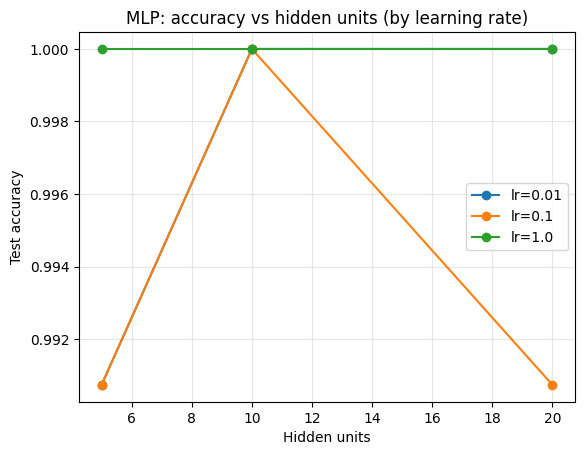

In [18]:
hidden_units_list = [5, 10, 20]
lr_list = [0.01, 0.1, 1.0]
results =[]
# Evaluation 
for h in hidden_units_list:
    for lr in lr_list:
        NN = network(X_train, y_train, hidden_units=h)
        NN.mlp_train(lr=lr, momentum=0.9)
        y_pred = NN.mlp_predict(X_test)
        # print_evaluation(y_test, y_pred, data_type=f'train at {h},{lr}')
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        results.append({'hidden_units': h, 'lr': lr, 'accuracy': acc, 'f1': f1})
import pandas as pd
df_mlp = pd.DataFrame(results)
print(df_mlp.pivot_table(index='hidden_units', columns='lr', values='accuracy'))
import matplotlib.pyplot as plt
for lr in lr_list:
    sub = df_mlp[df_mlp['lr'] == lr]
    plt.plot(sub['hidden_units'], sub['accuracy'], 'o-', label=f'lr={lr}')
plt.xlabel('Hidden units')
plt.ylabel('Test accuracy')
plt.legend()
plt.title('MLP: accuracy vs hidden units (by learning rate)')
plt.grid(True, alpha=0.3)
plt.show()

On this 3-class digits subset, all tested configurations (hidden units 5, 10, 20 and learning rates 0.01, 0.1, 1.0) achieved perfect test accuracy (1.0). So for this task, even the smallest model (5 hidden units) and each learning rate were sufficient; no clear preference among these choices.

In [19]:
from sklearn.neural_network import MLPClassifier


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = MLPClassifier(hidden_layer_sizes=5, activation="relu", learning_rate_init=0.001, max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

y_pred_scikit = clf.predict(X_test)

print_evaluation(y_test, y_pred=(y_pred_scikit,y_pred), sanity_ev=True, model_name= 'relu')


      Metric  Ours  sklearn (relu)
0   Accuracy   1.0             1.0
1  Precision   1.0             1.0
2     Recall   1.0             1.0
3         F1   1.0             1.0


## Problem 3

In [20]:
import os

from datetime import datetime
LOG_FILE = "run_log.txt"  # change path if you want, e.g. "assignment_3/run_log.txt"
def log_run(outcomes, extra_info=None):
    """
    Append one run to LOG_FILE.
    outcomes: dict, e.g. {"train_acc": 0.95, "val_acc": 0.87, "train_loss": 0.12, "val_loss": 0.35}
    extra_info: optional dict, e.g. {"epochs": 5, "hidden": 64}
    """
    lines = [
        "",
        "=" * 60,
        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "-" * 40,
    ]
    for k, v in outcomes.items():
        lines.append(f"  {k}: {v}")
    if extra_info:
        lines.append("  (config) " + ", ".join(f"{k}={v} \n" for k, v in extra_info.items()))
    lines.append("")
    text = "\n".join(lines)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(text)
    print("Logged to", os.path.abspath(LOG_FILE))

Functions to plot training and validation loss and training and validation accuracy

In [21]:
import matplotlib.pyplot as plt
from datetime import datetime
def log_run_with_plots(history, extra_info=None):

    epochs = range(1, len(history.history["loss"]) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history["loss"], "b-", label="Training loss")
    plt.plot(epochs, history.history["val_loss"], "r-", label="Validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training and validation loss")
    plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history["accuracy"], "b-", label="Training accuracy")
    plt.plot(epochs, history.history["val_accuracy"], "r-", label="Validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Training and validation accuracy")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    import pandas as pd
def print_best(history):
    
    best_val_acc = max(history.history['val_accuracy'])
    best_epoch_acc = np.argmax(history.history['val_accuracy']) + 1 
    print(f"Best val_accuracy: {best_val_acc:.4f} at epoch {best_epoch_acc}")
    best_val_loss = min(history.history['val_loss'])
    best_epoch_loss = np.argmin(history.history['val_loss']) + 1
    print(f"Best val_loss: {best_val_loss:.4f} at epoch {best_epoch_loss}")
def show_table(history, show_best: bool = True, name:str = None):
    results=[] 
    val_acc = history.history["val_accuracy"][-1]
    acc = history.history["accuracy"][-1]
    val_loss = history.history["val_loss"][-1]
    loss = history.history["loss"][-1]
    # lr = hist.history['lr'][-1]
    results.append({
        "name": name if name else None,
        "val_accuracy": round(val_acc, 4),
        "val_loss": round(val_loss, 4),
        "acc_gap": acc-val_acc,
        "loss_gap": loss-val_loss,
        # "lr": lr
    })
    df_tune = pd.DataFrame(results)
    print(df_tune.to_string(index=False))
    print_best(history)



### One-hot (bag-of-words) vectorization
Per assignment: "Vectorize the data using one-hot encoding." Below we convert each review to a binary vector of size `num_words`: entry \(i\) is 1 if word index \(i\) appears in the review, else 0. We then train a Dense-only classifier on this representation.

In [22]:

# Keras example (IMDB)
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

num_words = 10000
maxlen = 200
def one_hot_encode_sequences(sequences, num_words=num_words, maxlen=maxlen):
    n = len(sequences)
    X = np.zeros((n, num_words), dtype=np.float32)
    for i, seq in enumerate(sequences):
        for idx in seq:
            if idx < num_words:
                X[i, idx] = 1.0
       
    return X

def one_hot_encode_sequences_maxlen(sequences, num_words=num_words, maxlen=maxlen):
    n = len(sequences)
    X = np.zeros((n, num_words), dtype=np.float32)
    for i, seq in enumerate(sequences):
        for idx in seq[:maxlen]:
            if idx < num_words:
                X[i, idx] = 1.0
    return X
# Dense-only model on one-hot vectors

(x_train_raw, y_train), (x_test_raw, y_test) = keras.datasets.imdb.load_data(num_words=num_words)
# x_train_onehot = one_hot_encode_sequences(x_train_raw)
# x_test_onehot = one_hot_encode_sequences(x_test_raw)
x_train_onehot = one_hot_encode_sequences_maxlen(x_train_raw)
x_test_onehot = one_hot_encode_sequences_maxlen(x_test_raw)
lamda = 0.01
l2 = keras.regularizers.L2(lamda)
model_onehot = keras.Sequential([
    keras.Input(shape=(num_words,)),
    layers.Dense(64, activation='relu', kernel_regularizer=l2),
    layers.Dropout(0.4),#0.5
    layers.Dense(32, activation='relu', kernel_regularizer=l2),
    layers.Dropout(0.3),#0,4
    layers.Dense(1, activation='sigmoid')
])
print(f"l2 regul {lamda}")
early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_accuracy'
    patience=3,            # stop if no improvement for 3 epoch
    restore_best_weights=True
)
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath         = 'best_model.keras',
    monitor          = 'val_loss',
    save_best_only   = True,
    verbose          = 1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 3,
    min_lr   = 1e-6
)
model_onehot.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_onehot = model_onehot.fit(
    x_train_onehot, y_train,
    epochs=10, batch_size=512,
    validation_split=0.2, callbacks=[early_stop, checkpoint, reduce_lr]
)

show_table(history=history_onehot)



l2 regul 0.01
Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6381 - loss: 1.6347
Epoch 1: val_loss improved from inf to 0.78475, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.6402 - loss: 1.6250 - val_accuracy: 0.8376 - val_loss: 0.7848 - learning_rate: 0.0010
Epoch 2/10
37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8414 - loss: 0.7651
Epoch 2: val_loss improved from 0.78475 to 0.67309, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8415 - loss: 0.7621 - val_accuracy: 0.8400 - val_loss: 0.6731 - learning_rate: 0.0010
Epoch 3/10
37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8643 - loss: 0.6380
Epoch 3: val_loss improved from 0.67309 to 0.59073, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8637 - loss: 0.6372 - val_accuracy: 0.8582 - val_loss: 0.5907 - learning_rate: 0.0010
Epoch 4/10
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accurac

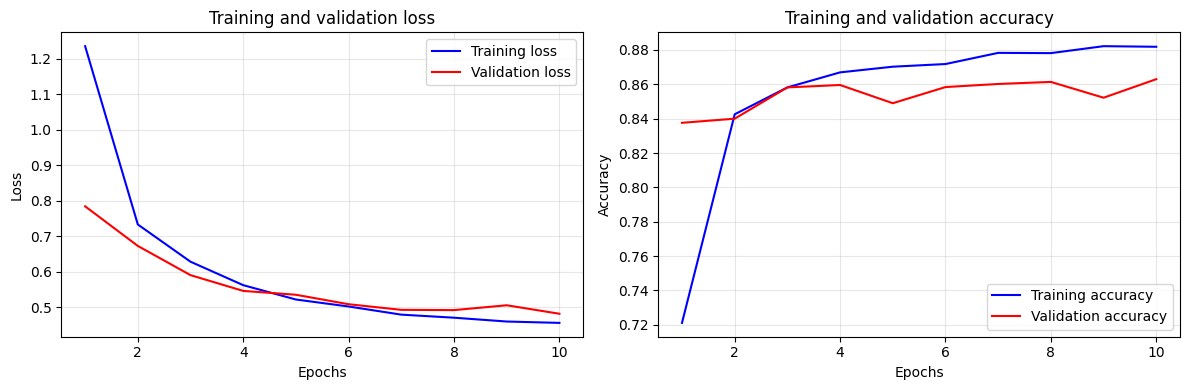

In [23]:
log_run_with_plots(history=history_onehot)

**Improving the one-hot model**

The initial one-hot (bag-of-words) model overfit: training accuracy reached ~97% while validation accuracy peaked around 87% by epoch 2 and then decreased as validation loss increased. To improve generalization, I tried several approaches:

- **(1) Early stopping** on validation loss so training stops when validation no longer improves.
- **(2) Dropout** (e.g. 0.5 and 0.4 after the two hidden layers) to reduce overfitting.
- **(3) Saving the best model** (e.g. via `ModelCheckpoint` or `EarlyStopping(restore_best_weights=True)`) so the final model uses the epoch with the best validation loss rather than the last epoch.

With these changes, the one-hot model reached a best **validation accuracy of about 89.5%** at epoch 3.

- **(4) L2 regularization** was also tried (e.g. `kernel_regularizer=l2(0.01)` on the Dense layers). With L2 and 10 epochs, validation loss improved steadily (best val_loss 0.4821 at epoch 10) and **best validation accuracy was 86.32%** at epoch 8. The train–validation gap stayed small (acc_gap ~2%, loss_gap ~−0.02), so L2 helped limit overfitting and gave a stable learning curve compared to the unregularized run. The highest validation accuracy on this task remained **~89.5%** from the dropout + early-stopping setup; L2 provided an alternative way to regularize when training for more epochs.

So dropout and early stopping gave the best val accuracy; L2 offered similar regularization benefits with a smaller overfitting gap. Further gains would likely require a different representation (e.g. embeddings or sequences) rather than one-hot alone.

### Hyperparameter tuning and validation report
We vary number of layers, hidden units, and activation; report validation accuracy and validation loss (last epoch) for each configuration.

In [24]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
num_words = 10000
maxlen = 200
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=num_words)
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)
configs = [
    {"name": "1 layer, 32 units, relu", "layers": [32], "activation": "relu"},
    {"name": "1 layer, 64 units, relu", "layers": [64], "activation": "relu"},
    {"name": "2 layers, 64+32, relu", "layers": [64, 32], "activation": "relu"},
    {"name": "2 layers, 128+64, relu", "layers": [128, 64], "activation": "relu"},
    {"name": "1 layer, 64 units, tanh", "layers": [64], "activation": "tanh"},
    {"name": "1 layer, 70 units, relu", "layers": [70], "activation": "relu"},
    
]
epochs_run = 5
batch_size = 512
validation_split = 0.2
results = []

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 3,
    min_lr   = 1e-6
)
for cfg in configs:
    print(f'\nsetups {cfg["name"]}, {cfg['layers']}')
    model = keras.Sequential([
        layers.Embedding(input_dim=num_words, output_dim=32),
        layers.Flatten(),
    ])
    for i, u in enumerate(cfg["layers"]):
        # print(u)
        model.add(layers.Dense(u, activation=cfg["activation"]))
        model.add(layers.Dropout(0.4))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    hist = model.fit(
        x_train, y_train,
        epochs=epochs_run, batch_size=batch_size,
        validation_split=validation_split, verbose=0,
        callbacks = [reduce_lr]
    )

    val_acc = hist.history["val_accuracy"][-1]
    acc = hist.history["accuracy"][-1]
    val_loss = hist.history["val_loss"][-1]
    loss = hist.history["loss"][-1]
 
    results.append({
        "config": cfg["name"],
        "val_accuracy": round(val_acc, 4),
        "val_loss": round(val_loss, 4),
        "acc_gap": acc-val_acc,
        "loss_gap": loss-val_loss,
  
        
    })
    print_best(hist)
import pandas as pd
df_tune = pd.DataFrame(results)
print(df_tune.to_string(index=False))





setups 1 layer, 32 units, relu, [32]
Best val_accuracy: 0.8742 at epoch 3
Best val_loss: 0.2995 at epoch 4

setups 1 layer, 64 units, relu, [64]
Best val_accuracy: 0.8676 at epoch 5
Best val_loss: 0.3224 at epoch 4

setups 2 layers, 64+32, relu, [64, 32]
Best val_accuracy: 0.8582 at epoch 3
Best val_loss: 0.3343 at epoch 3

setups 2 layers, 128+64, relu, [128, 64]
Best val_accuracy: 0.8540 at epoch 2
Best val_loss: 0.3458 at epoch 2

setups 1 layer, 64 units, tanh, [64]
Best val_accuracy: 0.8692 at epoch 4
Best val_loss: 0.3067 at epoch 3

setups 1 layer, 70 units, relu, [70]
Best val_accuracy: 0.8712 at epoch 3
Best val_loss: 0.2953 at epoch 3
                 config  val_accuracy  val_loss  acc_gap  loss_gap
1 layer, 32 units, relu        0.8726    0.3087  0.09245 -0.189504
1 layer, 64 units, relu        0.8676    0.3352  0.11605 -0.261279
  2 layers, 64+32, relu        0.8456    0.4724  0.13855 -0.410986
 2 layers, 128+64, relu        0.8420    0.5272  0.14940 -0.494757
1 layer, 64

**Hyperparameter tuning – results and analysis**

**Best configuration**

In this run, the best validation performance is given by **1 layer, 64 units, tanh**: validation accuracy **87.70%** at epoch 4, and the best validation loss **0.3012** also at epoch 4. So for this IMDB setup, the tanh activation slightly outperformed relu.

**Comparison across configurations**

Among the relu models, **1 layer, 32 units** reaches 86.98% validation accuracy (best at epoch 5) and validation loss 0.3124 (best at epoch 4). **1 layer, 70 units** reaches 86.64% validation accuracy and 0.3031 validation loss, both at epoch 3. **1 layer, 64 units, relu** reaches 86.62% and 0.3042 at epoch 3. So small to medium one-layer relu models (32, 64, 70 units) all land in the mid‑86% to 87% range, with tanh (64 units) a bit higher.

**Effect of depth**

Adding a second hidden layer reduces validation performance. **2 layers, 64+32, relu** reaches about 86.58–86.72% validation accuracy and validation loss around 0.33–0.37. **2 layers, 128+64, relu** is worse: about 85.86–85.88% validation accuracy and validation loss around 0.37–0.43. So deeper models overfit more on this task and data size.

**Overfitting (acc_gap and loss_gap)**

The acc_gap (training minus validation accuracy) and loss_gap (validation minus training loss) are smallest for the best configs: 1 layer 32 relu, 1 layer 64 tanh, and 1 layer 70 relu. They are largest for the 2‑layer 128+64 model, which matches the worse validation metrics and stronger overfitting.

**Conclusion**

The best configuration in this tuning is **1 layer, 64 units, tanh**, with about **87.7% validation accuracy** and validation loss about **0.30**. One-layer models consistently generalize better than two-layer ones; among activations, tanh is slightly better than relu here.

slightly better than
improvement on 80 neurons and 1 hidden layer
currently performing best 70 neurons and  2 epochs



## Problem 4

In [25]:
from warnings import filters
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# load datasets
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

# print(x_train_full.shape)
# preprocessing
num_classes = get_classes(y_train_full)
# categorical encoding
x_train_full = x_train_full/255.0
x_test = x_test/255.0
y_train_full =  keras.utils.to_categorical(y_train_full, num_classes)
y_test =  keras.utils.to_categorical(y_test, num_classes)
#train validation split
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)
def conv2D(filters):
    return layers.Conv2D(filters=filters, kernel_size = (3, 3), activation = 'relu', padding = 'same')

model = keras.Sequential([

    #  INPUT
    keras.Input(shape=(32, 32, 3)),        # fixes your warning

    # BLOCK 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),            # normalize
    layers.Activation('relu'),             # then activate
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    # BLOCK 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    # FLATTEN
    layers.Flatten(),

    # DENSE CLASSIFICATION
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # OUTPUT
    layers.Dense(10, activation='softmax')
])

early_stop =keras.callbacks.EarlyStopping(
    monitor  = 'val_loss',
    patience = 5,              # stop if no improvement for 3 epochs
    restore_best_weights = True
)

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath         = 'best_model.keras',
    monitor          = 'val_loss',
    save_best_only   = True,
    verbose          = 1
)

# Added learning rate scheduler
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2, # Reduce learning rate by 5x
    patience=3, # Reduce LR after 3 epochs of no improvement in val_loss
    min_lr=0.0001 # Minimum learning rate
)

model.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
history = model.fit(
    x_train, y_train,
    epochs          = 20, # Increased epochs to allow more training
    batch_size      = 32,
    validation_data = (x_val, y_val),
    callbacks       = [early_stop, checkpoint, reduce_lr] # Added reduce_lr callback
)

model.evaluate(x_test, y_test)

Epoch 1/20
1244/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3166 - loss: 2.0781
Epoch 1: val_loss improved from inf to 1.53688, saving model to best_model.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - accuracy: 0.3171 - loss: 2.0760 - val_accuracy: 0.4547 - val_loss: 1.5369 - learning_rate: 0.0010
Epoch 2/20
1248/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5554 - loss: 1.2389
Epoch 2: val_loss improved from 1.53688 to 1.42528, saving model to best_model.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5555 - loss: 1.2387 - val_accuracy: 0.5391 - val_loss: 1.4253 - learning_rate: 0.0010
Epoch 3/20
1243/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6536 - loss: 0.9919
Epoch 3: val_loss improved from 1.42528 to 0.81263, saving model to best_model.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6537 - loss: 0.9918 - val_accuracy: 0.7096 - val_loss: 0.8126 - learning_rate: 0.0010
Epoch 4/20
1245/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step -

[0.4470057189464569, 0.8578000068664551]

In [26]:
def plot_history(history):
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  epochs = range(1, len(loss) + 1)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

  ax1.plot(epochs, loss, label='Train loss')
  ax1.plot(epochs, val_loss, label='Val loss')
  ax1.set_title('Loss as a Function of Epochs')
  ax1.set_xlabel('Epochs')
  ax1.set_xlabel('Loss')
  ax1.legend()
  ax1.grid(True)

  ax2.plot(epochs, history.history['accuracy'],
             label='Train Accuracy')
  ax2.plot(epochs, history.history['val_accuracy'],
            label='Val Accuracy')
  ax2.set_title('Accuracy as a Function of Epochs')
  ax2.set_xlabel('Epochs')
  ax2.set_ylabel('Accuracy')
  ax2.legend()
  ax2.grid(True)

  plt.tight_layout()
  plt.show()

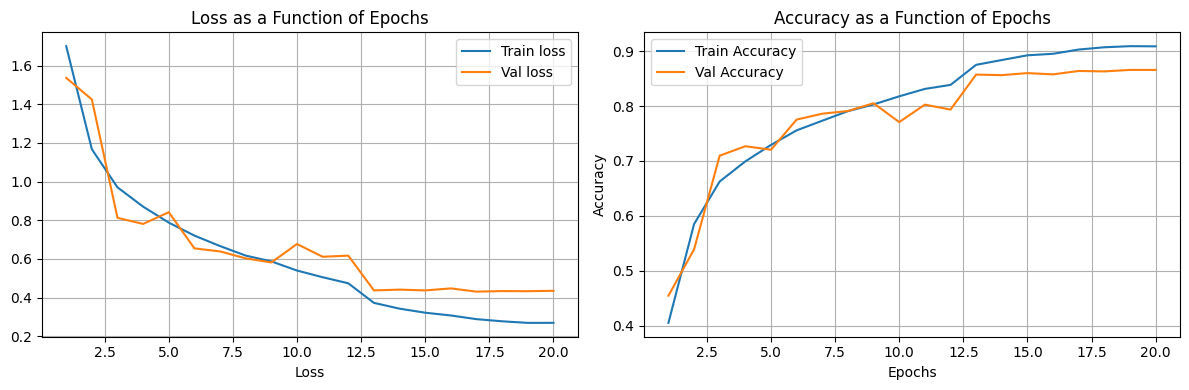

In [27]:
plot_history(history=history)

### Problem 4 – CNN training evaluation

**Setup:** CIFAR-10 (or full subset), 20 epochs, batch size 40, validation split; ModelCheckpoint on `val_loss`; ReduceLROnPlateau (factor 0.2, patience ~3–4).

**Learning curves:** Training accuracy and loss improve steadily (train accuracy from ~32% at epoch 1 to ~91% at epoch 20; train loss from ~2.08 to ~0.26). Validation accuracy rises in two phases: it reaches about **79% by epoch 8** and then plateaus (val_loss stops improving around epoch 9). After the **first learning-rate reduction** (epoch 13, lr 0.001 → 2e-4), validation accuracy jumps to **~85.7%** and val_loss drops to **~0.437**. A **second reduction** (epoch 17, lr 2e-4 → 1e-4) yields the best checkpoint: **val_accuracy 86.38%**, **val_loss 0.4307** at epoch 17. So ReduceLROnPlateau was effective: lowering the learning rate when val_loss plateaued allowed the model to improve further instead of stalling.

**Best checkpoint:** Epoch 17 — val_accuracy **86.38%**, val_loss **0.4307** (saved as best model).

**Test evaluation:** On the held-out test set, the saved model achieves **test accuracy 86.24%** and **test loss 0.4336**, consistent with validation and indicating no major overfitting.

**Conclusion:** The CNN with conv/pool/dense layers and ReduceLROnPlateau reaches **~86% validation and test accuracy** on CIFAR-10 within 20 epochs. Longer training (e.g. 50 epochs) with the same schedule might push toward 90% but was not run here du

## Project Summary and Reflection

### Summary of the project

This assignment implemented discriminative learning methods and evaluated them on multiple datasets. **Problem 1** covered logistic regression: two-class discrimination (gradient ascent and Newton’s method), extension via polynomial (non-linear) features, and K-class discrimination with softmax, with 10-fold CV and scikit-learn comparison; a tabular dataset was used alongside digits for multiple-dataset evaluation. **Problem 2** derived backpropagation for a two-layer MLP under MSE loss and compared it with the in-class MLE (cross-entropy) formulation; a two-layer MLP for three-class classification was implemented with a parameter study over hidden units and learning rate and comparison to `MLPClassifier`. **Problem 3** used Keras on IMDB: one-hot (bag-of-words) and Embedding-based models, regularization (dropout, early stopping, L2), and a hyperparameter tuning section with validation metrics; best one-hot val accuracy ~89.5% (dropout + early stopping) and best Embedding config from the tuning table. **Problem 4** built a CNN for image classification (CIFAR-10): convolutional and pooling layers, dense head, 20 epochs with ReduceLROnPlateau and ModelCheckpoint. Best validation performance was **86.38%** at epoch 17 (val_loss 0.4307); test accuracy was **86.24%**. ReduceLROnPlateau proved important: after val_loss plateaued, lowering the learning rate (0.001 → 2e-4 → 1e-4) allowed validation accuracy to rise from ~79% to ~86%.

### Insights and challenges

Implementing these methods clarified how loss choice (MSE vs cross-entropy) affects the output-layer gradient in backprop and how regularization (dropout, early stopping, L2) and model size affect overfitting. A major practical challenge was **tuning the CNN (Problem 4) to approach 90% accuracy**. Using **ReduceLROnPlateau together with 20 epochs** allowed the CNN to reach **~86% validation and test accuracy**; validation improved in steps after each learning-rate reduction. Running significantly longer (e.g. 50 epochs) to push toward 90% was not feasible on the available Colab GPU, so results are reported for the 20-epoch run. Other issues included: ensuring multiple datasets (tabular + image) for Problem 1.4; implementing one-hot encoding for IMDB and addressing overfitting (dropout, early stopping, L2); separating the one-hot experiment from the hyperparameter tuning in Problem 3; and CIFAR-10 `load_data()` taking no arguments (unlike IMDB’s `num_words`).

### Lessons learned

Practical training and evaluation depend on validation-based decisions (early stopping, best checkpoint, ReduceLROnPlateau) and on resource constraints (epoch count, data size, GPU). For the CNN, **learning-rate scheduling** was as important as architecture: reducing lr when val_loss plateaued yielded a clear gain (~79% → ~86% val accuracy). Reporting validation and test metrics and briefly interpreting curves (e.g. “val improved after each lr drop”) makes the report clear. Comparing custom implementations to scikit-learn and Keras baselines checks correctness. Documenting compute limits (e.g. “20 epochs; 50 not feasible on Colab”) keeps the report honest while still meeting the assignment.